In [ ]:
import sys
import warnings
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import polars as pl
import numpy as np

warnings.filterwarnings("ignore", message="Sortedness of columns cannot be checked.*")

project_root = Path.cwd()
while not (project_root / "requirements.txt").exists() and project_root != project_root.parent:
    project_root = project_root.parent
sys.path.append(str(project_root))
from scipy.stats import norm
from tests.fixtures.synthetic_data import synthetic_actual_df, synthetic_previous_df
from data import fetcher
from data.fetcher import (
fetch_data,
get_tommorows_wheather,
pair_dataframes,compute_forecast_error,
fetch_previous_forecast_data,
get_daily_max,
call_fetcher_functions,
build_polymarket_price_dataset,
)
from evaluation.calibration import (
get_guessed_prob,
calculate_buckets,

)

from models.bayesian_model import (
bayesian_interference,
posterior_probability,
)

from models.baseline import (
gaussian_probability
)
from models.kde_model import (
kde_estimate
)
from data.cleaner import clean_data
from data.loader import (
add_event_column,
filter_summer
)
from config.settings import (
HISTORICAL_START,
HISTORICAL_END,
DEFAULT_CITY,
TOMMORROWS_DATE,
FORECAST_START,
FORECAST_END,
LOWER_BOUND,
UPPER_BOUND,
IS_START,
IS_END,
OOS_START,
OOS_END,
)

from pricing.fair_value import (
get_daily_bucket,
)
from backtest.engine import engine

from evaluation.eval_loop import (
run_eval,
run_eval_loop_polymarket,
make_static_factory,
bayes_static_factory,
)
from evaluation.scoring import (
brier_score,
log_loss,
skill_score
)
from pricing.fair_value import ( 
create_buckets,
build_probability_vector,
find_correct_bucket,
build_daily_probability_vector,

)

from risk.kelly import kelly_criterion

from models import baseline
from models.bayesian_model import posterior_probability
from models.kde_model import kde_estimate
from data import fetcher, cleaner, loader
from config import settings

In [2]:
df_raw = fetch_data(IS_START,IS_END)
df_clean = clean_data(df_raw)
df_event = add_event_column(df_clean)
df_temp_summer = filter_summer(df_event)
df_summer = df_temp_summer["temperature_2m_max"].to_list()

df_pair = call_fetcher_functions(OOS_START, OOS_END)

df_result = build_polymarket_price_dataset()
print(df_result)
lst_buckets = get_daily_bucket(df_result)
lst_days  = df_result["date"].to_list()
#print(lst_buckets)







fetch_polymarket_data done after: 2.407568833004916 seconds
clean_polymarket_data done after: 2.431375874992227 seconds
filter_resolved done after: 2.4336872499989113 seconds
We are on 50 of 1954, this took 4.5 seconds 
We are on 100 of 1954, this took 6.16 seconds 
We are on 150 of 1954, this took 7.77 seconds 
We are on 200 of 1954, this took 14.86 seconds 
We are on 250 of 1954, this took 14.87 seconds 
We are on 300 of 1954, this took 15.29 seconds 
We are on 350 of 1954, this took 16.77 seconds 
We are on 400 of 1954, this took 18.21 seconds 
We are on 450 of 1954, this took 20.05 seconds 
We are on 500 of 1954, this took 22.98 seconds 
We are on 550 of 1954, this took 25.15 seconds 
We are on 600 of 1954, this took 26.48 seconds 
We are on 650 of 1954, this took 27.88 seconds 
We are on 700 of 1954, this took 29.4 seconds 
We are on 750 of 1954, this took 31.03 seconds 
We are on 800 of 1954, this took 32.99 seconds 
We are on 850 of 1954, this took 34.4 seconds 
We are on 900 of

/Users/gabriel/Desktop/Quant_Project/Quant-Summer-Project/data/loader.py:54: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided
  df_result = df_loaded.join_asof(df_prices,left_on = "target" , right_on = "t",by = "yes_token_id",strategy = "backward")


In [3]:

gaussian_prob_fn = lambda low, high: gaussian_probability(df_summer, low, high)[0]
kde_prob_fn = lambda low, high: kde_estimate(df_summer, low, high)
bayesian_prob_fn = lambda day, low, high: posterior_probability(df_summer, day, df_pair, low, high)

p_gauss = build_probability_vector(gaussian_prob_fn, lst_buckets)
p_kde =  build_probability_vector(kde_prob_fn, lst_buckets)
p_bayes = build_daily_probability_vector(bayesian_prob_fn, lst_buckets,lst_days)


gauss_factory = make_static_factory(gaussian_prob_fn)
kde_factory = make_static_factory(kde_prob_fn)
bayes_factory =  bayes_static_factory(bayesian_prob_fn)

buckets = create_buckets(LOWER_BOUND,UPPER_BOUND) 


df_res_gauss = run_eval_loop_polymarket(gauss_factory,buckets,df_pair,df_result)
df_res_kde = run_eval_loop_polymarket(kde_factory,buckets,df_pair,df_result)
df_res_bayes = run_eval_loop_polymarket(bayes_factory,buckets,df_pair,df_result)



gauss_engine = engine(p_gauss,df_res_gauss)
kde_engine = engine(p_kde,df_res_kde)

bayes_engine = engine(p_bayes,df_res_bayes)

print(gauss_engine["stake"].describe() )
print(kde_engine["stake"].describe() )
print(bayes_engine["stake"].describe() )





shape: (9, 2)
┌────────────┬──────────┐
│ statistic  ┆ value    │
│ ---        ┆ ---      │
│ str        ┆ f64      │
╞════════════╪══════════╡
│ count      ┆ 653.0    │
│ null_count ┆ 0.0      │
│ mean       ┆ 0.110048 │
│ std        ┆ 0.080065 │
│ min        ┆ 0.017219 │
│ 25%        ┆ 0.043262 │
│ 50%        ┆ 0.071223 │
│ 75%        ┆ 0.181191 │
│ max        ┆ 0.249843 │
└────────────┴──────────┘
shape: (9, 2)
┌────────────┬──────────┐
│ statistic  ┆ value    │
│ ---        ┆ ---      │
│ str        ┆ f64      │
╞════════════╪══════════╡
│ count      ┆ 661.0    │
│ null_count ┆ 0.0      │
│ mean       ┆ 0.109762 │
│ std        ┆ 0.079887 │
│ min        ┆ 0.01715  │
│ 25%        ┆ 0.041077 │
│ 50%        ┆ 0.072497 │
│ 75%        ┆ 0.185464 │
│ max        ┆ 0.249869 │
└────────────┴──────────┘
shape: (9, 2)
┌────────────┬──────────┐
│ statistic  ┆ value    │
│ ---        ┆ ---      │
│ str        ┆ f64      │
╞════════════╪══════════╡
│ count      ┆ 653.0    │
│ null_count ┆ 0.0    

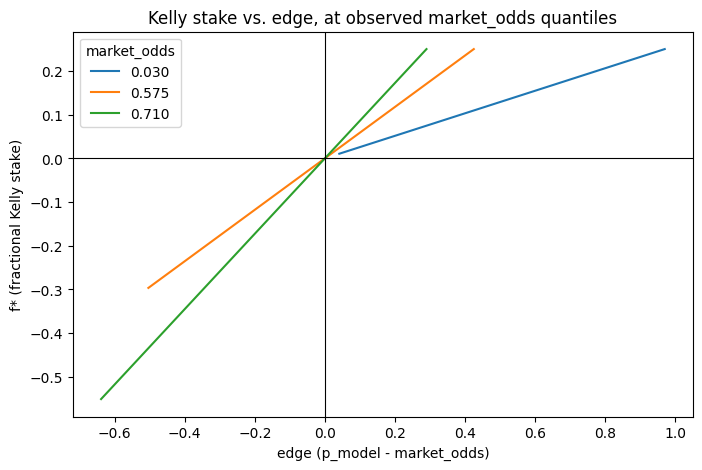

In [4]:
observed_odds = pl.concat([gauss_engine["price_paid"], kde_engine["price_paid"], bayes_engine["price_paid"]])
observed_p = pl.concat([gauss_engine["model_side"], kde_engine["model_side"], bayes_engine["model_side"]])

odds_fixed = [observed_odds.quantile(0.25), observed_odds.quantile(0.5), observed_odds.quantile(0.75)]
p_model_range = np.linspace(observed_p.min(), observed_p.max(), 200)

edge_records = []
for odds in odds_fixed:
    f_star = kelly_criterion(p_model_range, [odds] * len(p_model_range)).to_numpy()
    edge = p_model_range - odds
    edge_records.append(pl.DataFrame({"edge": edge, "f_star": f_star, "market_odds": [f"{odds:.3f}"] * len(edge)}))
df_edge_sweep = pl.concat(edge_records).to_pandas()

fig, ax = plt.subplots(figsize=(8, 5))
sns.lineplot(data=df_edge_sweep, x="edge", y="f_star", hue="market_odds", ax=ax)
ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("edge (p_model - market_odds)")
ax.set_ylabel("f* (fractional Kelly stake)")
ax.set_title("Kelly stake vs. edge, at observed market_odds quantiles")
plt.show()

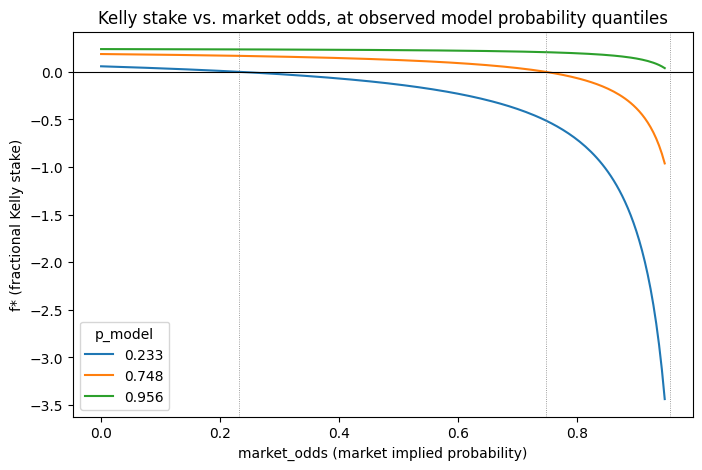

In [5]:
p_fixed = [observed_p.quantile(0.25), observed_p.quantile(0.5), observed_p.quantile(0.75)]
odds_range = np.linspace(observed_odds.min(), observed_odds.max(), 200)

odds_records = []
for p in p_fixed:
    f_star = kelly_criterion([p] * len(odds_range), odds_range).to_numpy()
    odds_records.append(pl.DataFrame({"market_odds": odds_range, "f_star": f_star, "p_model": [f"{p:.3f}"] * len(odds_range)}))
df_odds_sweep = pl.concat(odds_records).to_pandas()

fig, ax = plt.subplots(figsize=(8, 5))
sns.lineplot(data=df_odds_sweep, x="market_odds", y="f_star", hue="p_model", ax=ax)
for p in p_fixed:
    ax.axvline(p, color="gray", linewidth=0.6, linestyle=":")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("market_odds (market implied probability)")
ax.set_ylabel("f* (fractional Kelly stake)")
ax.set_title("Kelly stake vs. market odds, at observed model probability quantiles")
plt.show()

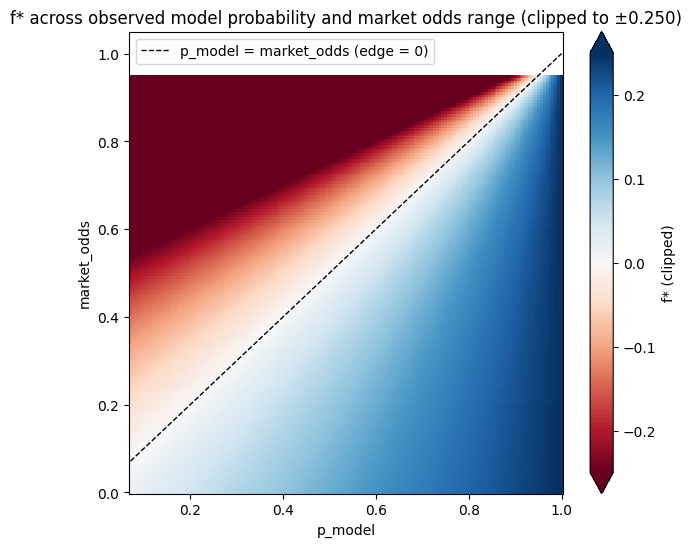

In [6]:
p_grid = np.linspace(observed_p.min(), observed_p.max(), 150)
odds_grid = np.linspace(observed_odds.min(), observed_odds.max(), 150)
P, O = np.meshgrid(p_grid, odds_grid)
F = kelly_criterion(P.ravel(), O.ravel()).to_numpy().reshape(P.shape)

observed_stake = pl.concat([gauss_engine["stake"], kde_engine["stake"], bayes_engine["stake"]])
CLIP = observed_stake.abs().max()
F_display = np.clip(F, -CLIP, CLIP)

fig, ax = plt.subplots(figsize=(7, 6))
mesh = ax.pcolormesh(p_grid, odds_grid, F_display, cmap="RdBu", vmin=-CLIP, vmax=CLIP, shading="auto")
ax.plot(p_grid, p_grid, color="black", linewidth=1, linestyle="--", label="p_model = market_odds (edge = 0)")
ax.set_xlabel("p_model")
ax.set_ylabel("market_odds")
ax.set_title(f"f* across observed model probability and market odds range (clipped to ±{CLIP:.3f})")
ax.legend()
fig.colorbar(mesh, label="f* (clipped)", extend="both")
plt.show()